In [1]:
from google.colab import files
uploaded = files.upload()

Saving Movies_Final_Combined (2) (2).xlsx to Movies_Final_Combined (2) (2).xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read only the Global Movies Sample sheet
df = pd.read_excel("Movies_Final_Combined (2) (2).xlsx",
                   sheet_name="Global_Movies_Sample")

# Display first 5 rows
df.head()

,title,year,genre,duration,rating,votes,revenue_million,budget_million,language,country,ott_platforms,content_rating,metascore,popularity,awards_won
0,Spider-Man: No Way Home 1452,2002,"Romance, Biography",88,6.9,1804482,101.5,117.0,French,India,"Prime Video, HBO Max, Apple TV+",G,67,65.0,9
1,Joker 66,1962,"Romance, Sci-Fi",84,8.1,1033296,2468.7,461.2,Spanish,South Korea,"Apple TV+, Disney+, HBO Max",PG,71,66.5,16
2,Parasite 415,2003,Sci-Fi,178,6.0,999683,1057.4,332.6,Korean,India,"Apple TV+, Netflix, Prime Video",PG-13,55,27.3,19
3,Frozen 2009,1956,"Horror, Adventure",145,6.6,2501259,2396.0,209.3,Hindi,India,"Netflix, Prime Video, HBO Max",PG,83,71.2,10
4,Pathaan 1445,2002,"Horror, Fantasy, Comedy",95,4.6,41776,1487.9,165.1,Korean,UK,"Disney+, HBO Max",G,66,96.2,6


In [8]:
df.columns

Index(['title', 'year', 'genre', 'duration', 'rating', 'votes',
       'revenue_million', 'budget_million', 'language', 'country',
       'ott_platforms', 'content_rating', 'metascore', 'popularity',
       'awards_won'],
      dtype='object')

In [4]:
df.shape

(100, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            100 non-null    object 
 1   year             100 non-null    int64  
 2   genre            100 non-null    object 
 3   duration         100 non-null    int64  
 4   rating           100 non-null    float64
 5   votes            100 non-null    int64  
 6   revenue_million  100 non-null    float64
 7   budget_million   100 non-null    float64
 8   language         100 non-null    object 
 9   country          100 non-null    object 
 10  ott_platforms    100 non-null    object 
 11  content_rating   100 non-null    object 
 12  metascore        100 non-null    int64  
 13  popularity       100 non-null    float64
 14  awards_won       100 non-null    int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 11.8+ KB


In [6]:
df.isnull().sum()

,0
title,0
year,0
genre,0
duration,0
rating,0
votes,0
revenue_million,0
budget_million,0
language,0
country,0


In [9]:
df.dtypes

,0
title,object
year,int64
genre,object
duration,int64
rating,float64
votes,int64
revenue_million,float64
budget_million,float64
language,object
country,object


In [7]:
df.describe()

,year,duration,rating,votes,revenue_million,budget_million,metascore,popularity,awards_won
count,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1989.340000,127.130000,6.686000,1.535344e+06,1302.842000,262.339000,61.520000,55.997000,10.050000
std,21.155614,28.534811,1.647957,9.456414e+05,765.296167,153.638417,17.807886,26.529448,5.831601
min,1950.000000,80.000000,4.000000,6.720000e+03,9.600000,2.200000,30.000000,10.400000,0.000000
25%,1970.000000,104.000000,5.175000,7.270955e+05,663.950000,110.450000,48.000000,32.775000,5.750000
50%,1990.500000,126.500000,6.650000,1.588502e+06,1296.050000,290.300000,59.000000,57.350000,10.000000
75%,2005.500000,150.250000,8.125000,2.369890e+06,1981.200000,395.325000,75.250000,79.725000,15.000000
max,2025.000000,179.000000,9.500000,2.994658e+06,2468.700000,498.600000,94.000000,99.700000,20.000000


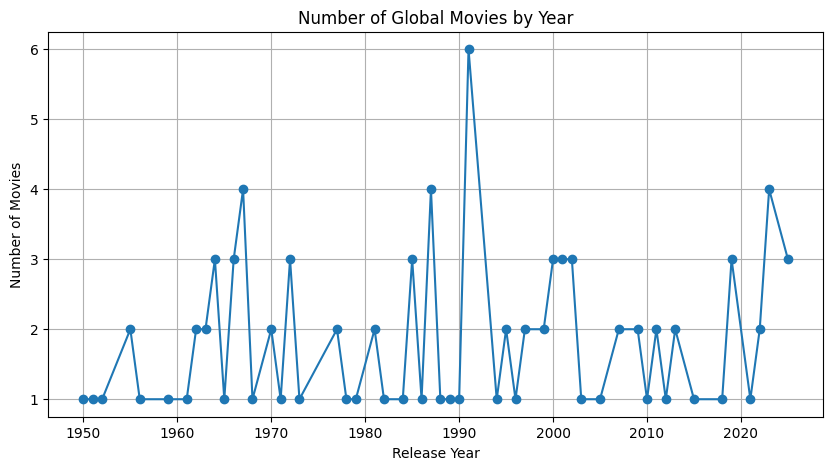

In [11]:
year_count = df['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(year_count.index,
         year_count.values,
         marker='o')

plt.title('Number of Global Movies by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')

plt.grid(True)
plt.show()

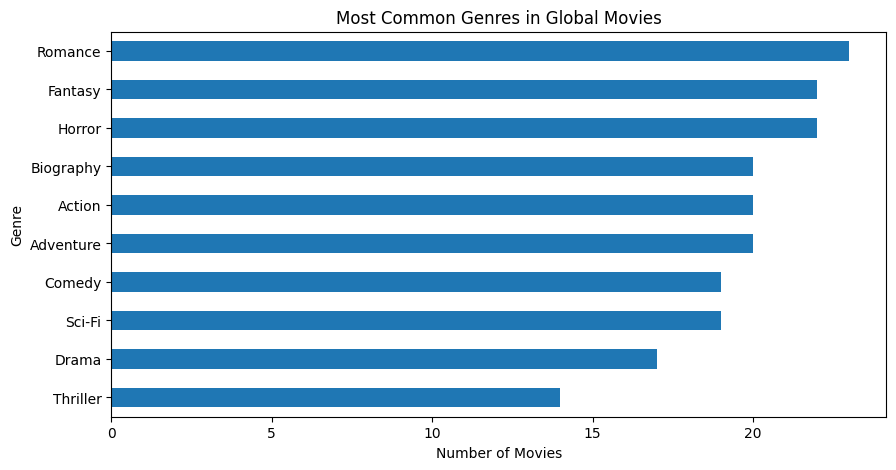

In [12]:
genre_count = (
    df['genre']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

plt.figure(figsize=(10,5))

genre_count.sort_values().plot(kind='barh')

plt.title('Most Common Genres in Global Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')

plt.show()

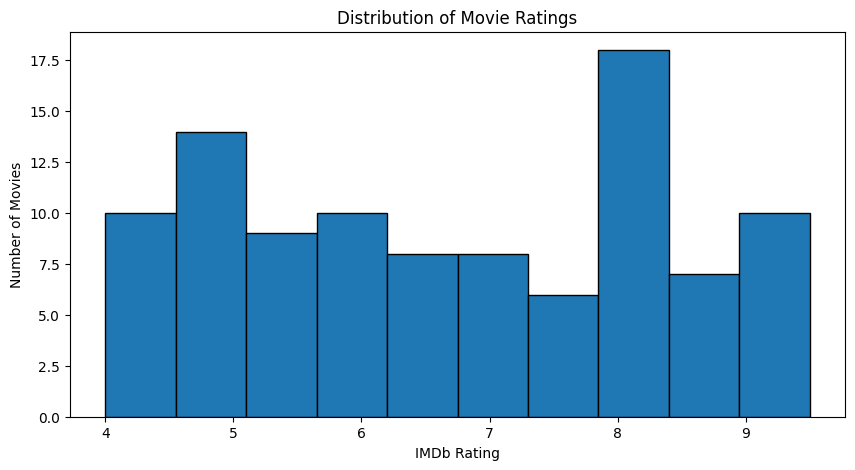

In [14]:
plt.figure(figsize=(10,5))

plt.hist(df['rating'],
         bins=10,
         edgecolor='black')

plt.title('Distribution of Movie Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Number of Movies')

plt.show()

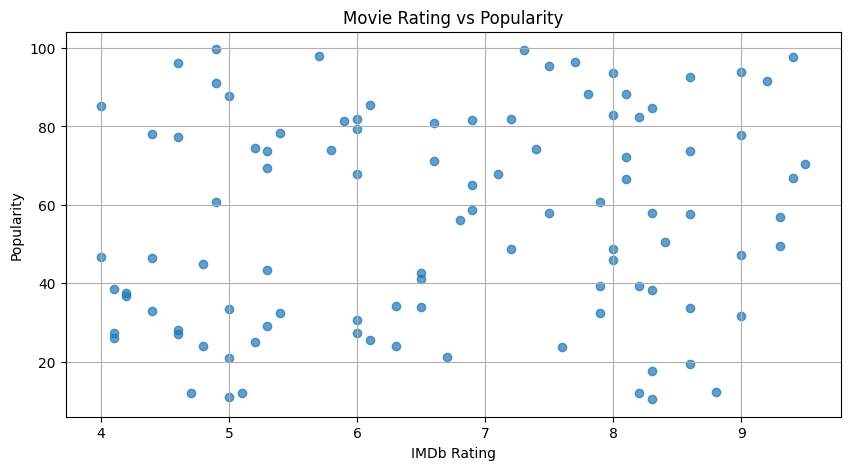

In [15]:
plt.figure(figsize=(10,5))

plt.scatter(df['rating'],
            df['popularity'],
            alpha=0.7)

plt.title('Movie Rating vs Popularity')
plt.xlabel('IMDb Rating')
plt.ylabel('Popularity')

plt.grid(True)
plt.show()

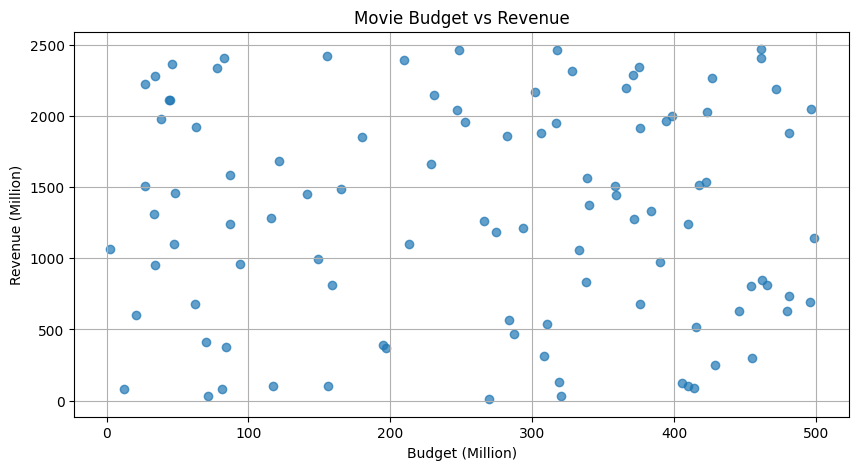

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(df['budget_million'],
            df['revenue_million'],
            alpha=0.7)

plt.title('Movie Budget vs Revenue')
plt.xlabel('Budget (Million)')
plt.ylabel('Revenue (Million)')

plt.grid(True)
plt.show()

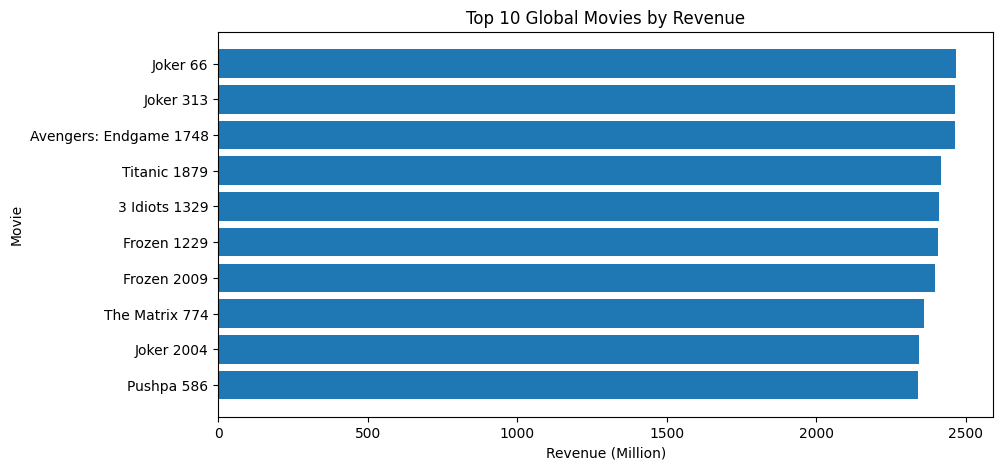

In [18]:
top_revenue = df.nlargest(10, 'revenue_million')

plt.figure(figsize=(10,5))

plt.barh(top_revenue['title'],
         top_revenue['revenue_million'])

plt.title('Top 10 Global Movies by Revenue')
plt.xlabel('Revenue (Million)')
plt.ylabel('Movie')

plt.gca().invert_yaxis()

plt.show()

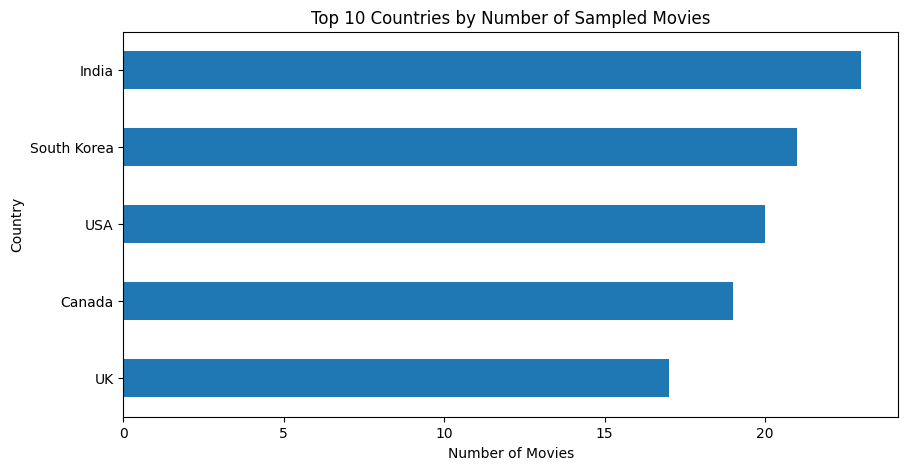

In [20]:
country_count = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

country_count.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Number of Sampled Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Country')

plt.show()

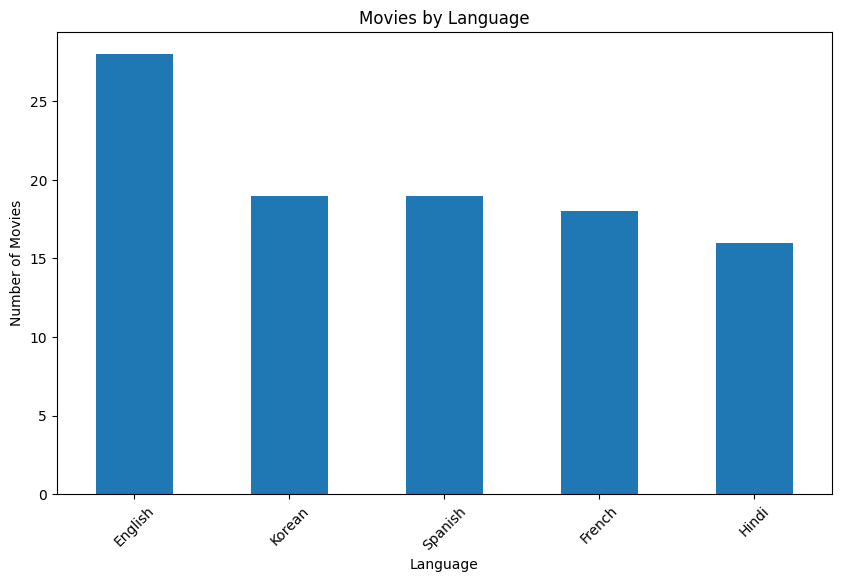

In [21]:
language_count = df['language'].value_counts()

plt.figure(figsize=(10,6))

language_count.plot(kind='bar')

plt.title('Movies by Language')
plt.xlabel('Language')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45)

plt.show()

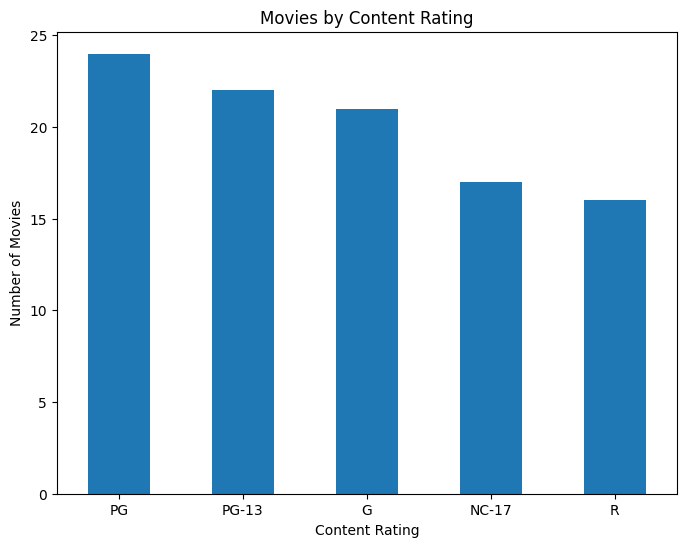

In [22]:
content_rating_count = df['content_rating'].value_counts()

plt.figure(figsize=(8,6))

content_rating_count.plot(kind='bar')

plt.title('Movies by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Movies')

plt.xticks(rotation=0)

plt.show()